In [1]:
!nvidia-smi

Mon Jun  8 07:29:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 596.49                 Driver Version: 596.49         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3070 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   40C    P8             16W /  130W |    1727MiB /   8192MiB |      6%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
from pathlib import Path
project_dir = Path.cwd().parent

In [3]:
from rfdetr import RFDETRMedium
import torch

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Memory Allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
    print(f"Memory Cached: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")

Using device: cuda
GPU Name: NVIDIA GeForce RTX 3070 Laptop GPU
Memory Allocated: 0.00 GB
Memory Cached: 0.00 GB


In [5]:
model = RFDETRMedium(num_classes=12)

model.train(
    dataset_dir=str(project_dir / 'data' / 'ChessmanDetection.v5.coco'),
    output_dir=str(project_dir / 'models' / 'rfdetr_medium'),
    resume=str(project_dir / 'models' / 'rfdetr_medium' / 'last.ckpt'),
    epochs=50,
    resolution=576,
    aug_config={
        "HorizontalFlip": {"p": 0.5}
    },
    checkpoint_interval=5,
    batch_size=4,
    grad_accum_steps=4,
    lr=1e-4,
    lr_scheduler='step',
    tensorboard=True,
    device=device
)

[2026-06-08 07:29:55] [INFO] rf-detr - File C:\Users\feran\.roboflow\models\rf-detr-medium.pth already exists with correct MD5 hash.


[2026-06-08 07:29:55] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-08 07:29:55] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-06-08 07:29:56] [INFO] rf-detr - File C:\Users\feran\.roboflow\models\rf-detr-medium.pth already exists with correct MD5 hash.


[2026-06-08 07:29:57] [WARNING] rf-detr - Checkpoint has 90 classes but model is configured for 12. The detection head will be re-initialized to 12 classes.
W0608 07:29:58.225000 32392 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
[2026-06-08 07:29:58] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-08 07:29:58] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-06-08 07:29:59] [INFO] rf-detr - File C:\Users\feran\.roboflow\models\rf-detr-medium.pth already exists with correct MD5 hash.


...

Restored all states from the checkpoint at c:\Users\feran\Projects\chessify\models\rfdetr_medium\last.ckpt
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Output()

[2026-06-08 07:41:52] [INFO] rf-detr - Best regular mAP saved to C:\Users\feran\Projects\chessify\models\rfdetr_medium\checkpoint_best_regular.pth (epoch 48)


`Trainer.fit` stopped: `max_epochs=50` reached.


[2026-06-08 07:58:41] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.6922, ema=0.6997)


In [22]:
from rfdetr import RFDETRMedium
model = RFDETRMedium(pretrain_weights=str(project_dir / 'models' / 'rfdetr_medium' / 'checkpoint_best_total.pth'), num_classes=12)
label_list = ["B", "K", "N", "P", "Q", "R", "b", "k", "n", "p", "q", "r"]

[2026-06-08 08:17:46] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-08 08:17:46] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-08 08:17:46] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.


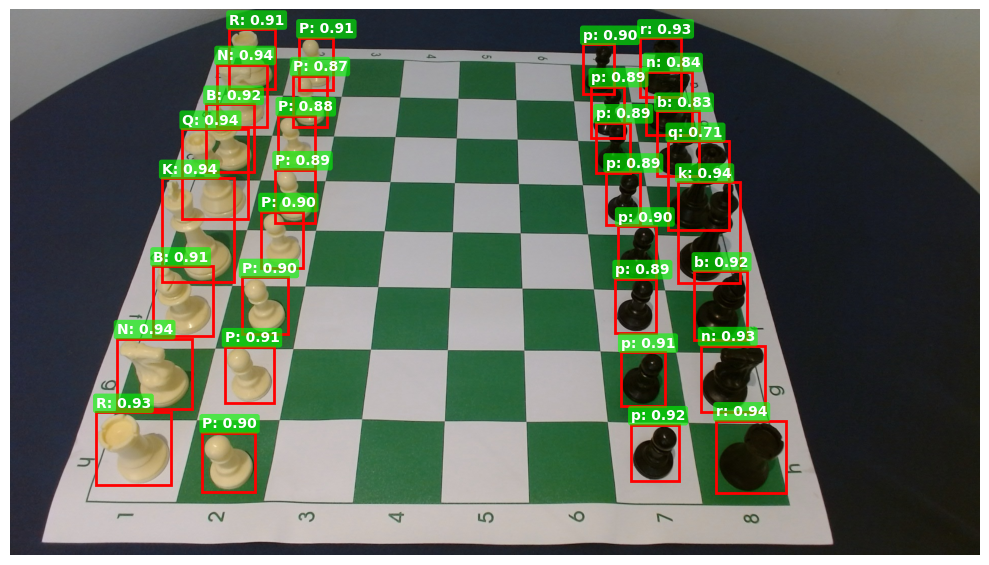

In [33]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
image_path = str(project_dir / "notebooks" / "game_opera_side" / "game_opera0.jpg")
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

predictions = model.predict(image_rgb, threshold=0.5)

fig, ax = plt.subplots(1, figsize=(10, 6))
ax.imshow(image_rgb)

for box, label, score in zip(predictions.xyxy, predictions.class_id, predictions.confidence):
    xmin, ymin, xmax, ymax = box
    width = xmax - xmin
    height = ymax - ymin
    
    rect = patches.Rectangle(
        (xmin, ymin), width, height, 
        linewidth=2, edgecolor='r', facecolor='none'
    )
    ax.add_patch(rect)
    
    text = f"{label_list[label]}: {score:.2f}"
    ax.text(
        xmin, ymin - 10, text, 
        color="white", fontsize=10, weight="bold",
        bbox=dict(facecolor="lime", alpha=0.6, edgecolor="none", boxstyle="round,pad=0.2")
    )

plt.axis("off")
plt.tight_layout()
plt.show()


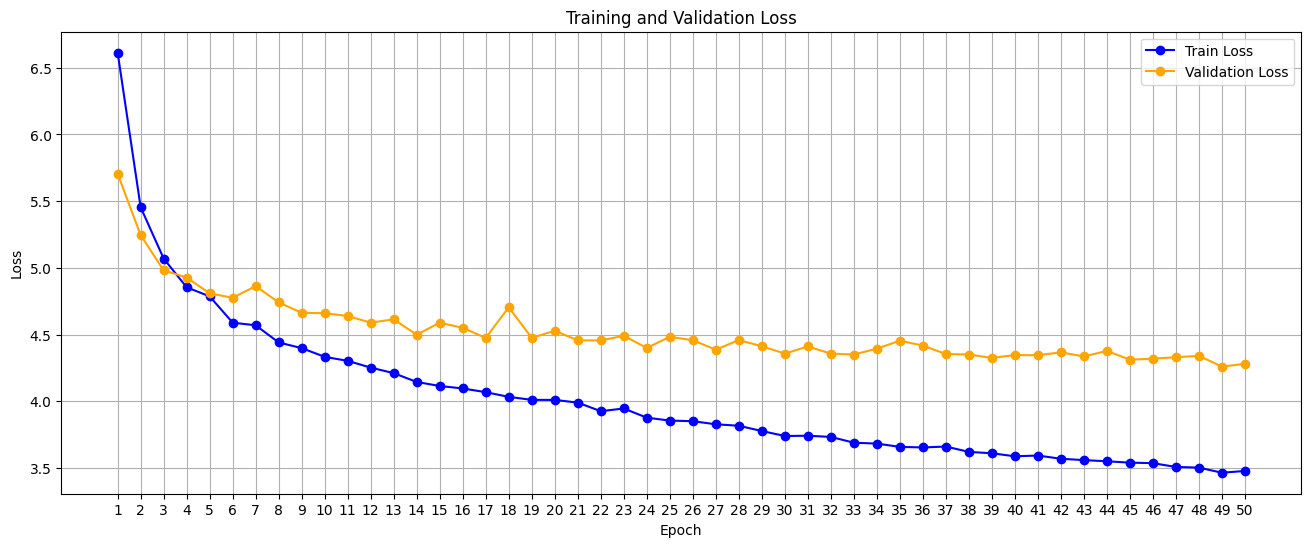

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

metrics = pd.read_csv(project_dir / 'models' / 'rfdetr_medium' / 'metrics.csv')
epochs = (metrics['epoch'] + 1).drop_duplicates(keep='last').reset_index(drop=True)
train_losses = (metrics['train/loss']).dropna().reset_index(drop=True)
val_losses = (metrics['val/loss']).dropna().reset_index(drop=True)
plt.figure(figsize=(16, 6))
plt.plot(epochs, train_losses, label='Train Loss', color='blue', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', color='orange', marker='o')
plt.xticks(range(1, metrics['epoch'].max() + 2))
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='best')
plt.grid()
plt.show()

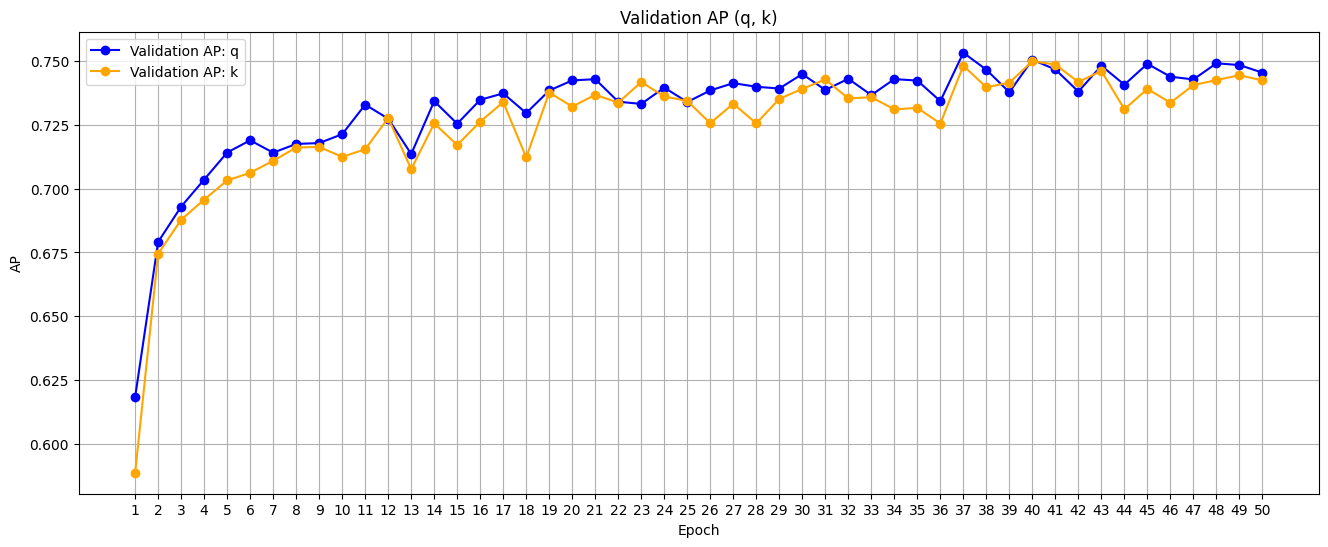

In [15]:
valAPq = (metrics['val/AP/q']).dropna().reset_index(drop=True)
valAPk = (metrics['val/AP/k']).dropna().reset_index(drop=True)
plt.figure(figsize=(16, 6))
plt.plot(epochs, valAPq, label='Validation AP: q', color='blue', marker='o')
plt.plot(epochs, valAPk, label='Validation AP: k', color='orange', marker='o')
plt.xticks(range(1, metrics['epoch'].max() + 2))
plt.xlabel('Epoch')
plt.ylabel('AP')
plt.title('Validation AP (q, k)')
plt.legend(loc='best')
plt.grid()
plt.show()

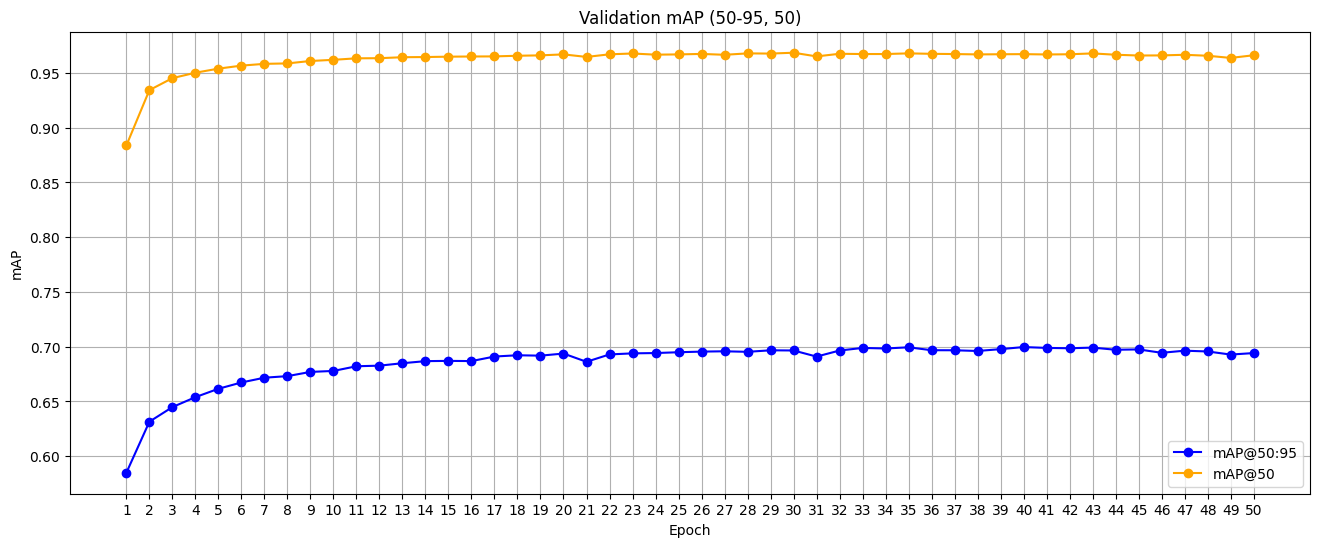

In [16]:
mAP50_95 = (metrics['val/ema_mAP_50_95']).dropna().reset_index(drop=True)
mAP50 = (metrics['val/ema_mAP_50']).dropna().reset_index(drop=True)
plt.figure(figsize=(16, 6))
plt.plot(epochs, mAP50_95, label='mAP@50:95', color='blue', marker='o')
plt.plot(epochs, mAP50, label='mAP@50', color='orange', marker='o')
plt.xticks(range(1, metrics['epoch'].max() + 2))
plt.xlabel('Epoch')
plt.ylabel('mAP')
plt.title('Validation mAP (50-95, 50)')
plt.legend(loc='best')
plt.grid()
plt.show()